# Lab 2: Simplified Region-based Object Detection (Faster R-CNN inspired)

# Goal: Understand region proposals → ROI pooling → classification & box regression

In [16]:
import tensorflow as tf

# Disable XLA JIT (fix for crop_and_resize)
tf.config.optimizer.set_jit(False)

In [23]:
tf.config.run_functions_eagerly(True)

In [25]:
import tensorflow as tf

# Disable XLA GPU compilation
tf.config.optimizer.set_jit(False)

# Run TensorFlow eagerly (safer for custom layers)
tf.config.run_functions_eagerly(True)

In [24]:
tf.config.run_functions_eagerly(True)
model = build_simple_detector(num_classes=21)

In [17]:
import tensorflow as tf

from tensorflow import keras

from tensorflow.keras import layers

import numpy as np

import cv2

import matplotlib.pyplot as plt

# 1. Load pre-trained backbone (feature extractor)

In [18]:
backbone = keras.applications.ResNet50(

    include_top=False,

    weights='imagenet',

    input_shape=(None, None, 3)

)



# Freeze early layers

for layer in backbone.layers[:100]:

    layer.trainable = False



print("Backbone loaded (ResNet50)")

Backbone loaded (ResNet50)


# 2. Simple Anchor Generator (9 anchors per position)

In [19]:
def generate_anchors(feature_map_shape, ratios=[0.5,1,2], scales=[0.5,1,2]):

    """

    Generate anchor boxes for each position in feature map

    Returns: (N,4) → [y1,x1,y2,x2] normalized

    """

    h, w = feature_map_shape[:2]

    anchors = []



    for i in range(h):

        for j in range(w):

            cx = (j + 0.5) / w

            cy = (i + 0.5) / h



            for r in ratios:

                for s in scales:

                    area = s**2

                    w_a = np.sqrt(area / r)

                    h_a = w_a * r

                    x1 = cx - w_a/2

                    y1 = cy - h_a/2

                    x2 = cx + w_a/2

                    y2 = cy + h_a/2

                    anchors.append([y1,x1,y2,x2])



    return np.array(anchors, dtype=np.float32)

In [20]:
class ROIPooling(layers.Layer):
    def __init__(self, pool_size=(7,7)):
        super().__init__()
        self.pool_size = pool_size

    def call(self, inputs):

        feature_map, boxes = inputs
        batch_size = tf.shape(feature_map)[0]
        num_rois = tf.shape(boxes)[1]

        # reshape boxes → (batch*num_rois,4)
        boxes_reshaped = tf.reshape(boxes, (-1,4))

        # create batch indices
        batch_indices = tf.repeat(tf.range(batch_size), num_rois)

        pooled = tf.image.crop_and_resize(
            feature_map,
            boxes_reshaped,
            batch_indices,
            self.pool_size
        )

        return pooled

In [21]:
def build_simple_detector(num_classes=21):

    inputs = keras.Input(shape=(None, None, 3))

    # Backbone feature map
    features = backbone(inputs)

    # Random proposals (simplified replacement for RPN)
    proposals = layers.Lambda(
        lambda x: tf.random.uniform((tf.shape(x)[0], 128, 4), 0, 1)
    )(features)

    # ROI Pooling
    pooled = ROIPooling((7,7))([features, proposals])

    # Detection head
    x = layers.GlobalAveragePooling2D()(pooled)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    class_logits = layers.Dense(num_classes, name='cls')(x)
    box_deltas  = layers.Dense(4*num_classes, name='reg')(x)

    model = keras.Model(inputs, [class_logits, box_deltas])

    return model


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, None,      │ 23,587,712 │ input_layer_10[0… │
│ (Functional)        │ None, 2048)       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_8 (Lambda)   │ (None, 128, 4)    │          0 │ resnet50[3][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roi_pooling_7       │ (None, 7, 7,      │          0 │ resnet50[3][0],   │
│ (ROIPooling)        │ 2048)             │            │ lambda_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ roi_pooling_7[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 512)       │  1,049,088 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 512)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls (Dense)         │ (None, 21)        │     10,773 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg (Dense)         │ (None, 84)        │     43,092 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,690,665 (94.19 MB)

 Trainable params: 20,555,881 (78.41 MB)

 Non-trainable params: 4,134,784 (15.77 MB)

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step
Inference done. (This is simplified – real training needed)


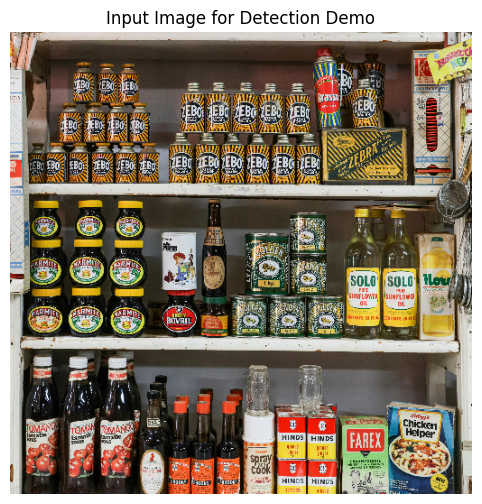

Lab notes:
• This is a **very simplified** Faster R-CNN-style pipeline
• In real Faster R-CNN you need:
  - Anchor generation + RPN training
  - Proposal refinement
  - ROI Align (better than simple pooling)
  - Multi-task loss (cls + smooth L1 regression)
• Next step: replace random proposals with real RPN output


In [37]:
model = build_simple_detector(num_classes=21)

model.summary()



# Load any test image (replace path)

img_path = "/content/object.jpg"   # ← put your own image here

img = cv2.imread(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(img, (512, 512))

img_input = np.expand_dims(img_resized.astype(np.float32)/255., 0)



# Dummy inference (random proposals → random results)

cls, reg = model.predict(img_input)



print("Inference done. (This is simplified – real training needed)")



# Visualize input

plt.figure(figsize=(8,6))

plt.imshow(img_resized)

plt.title("Input Image for Detection Demo")

plt.axis('off')

plt.show()



print("Lab notes:")

print("• This is a **very simplified** Faster R-CNN-style pipeline")

print("• In real Faster R-CNN you need:")

print("  - Anchor generation + RPN training")

print("  - Proposal refinement")

print("  - ROI Align (better than simple pooling)")

print("  - Multi-task loss (cls + smooth L1 regression)")

print("• Next step: replace random proposals with real RPN output")

<hr>

# 1. MODEL SETUP
<hr>
# Load a pre-trained Faster R-CNN model from TF Hub.
# This model uses a ResNet50 backbone and was trained on the COCO dataset.


In [30]:
import tensorflow_hub as hub

MODEL_URL = "https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_640x640/1"
detector = hub.load(MODEL_URL)
print("Model loaded successfully!")

Model loaded successfully!



# 2. IMAGE PREPROCESSING


Scanning image for objects...


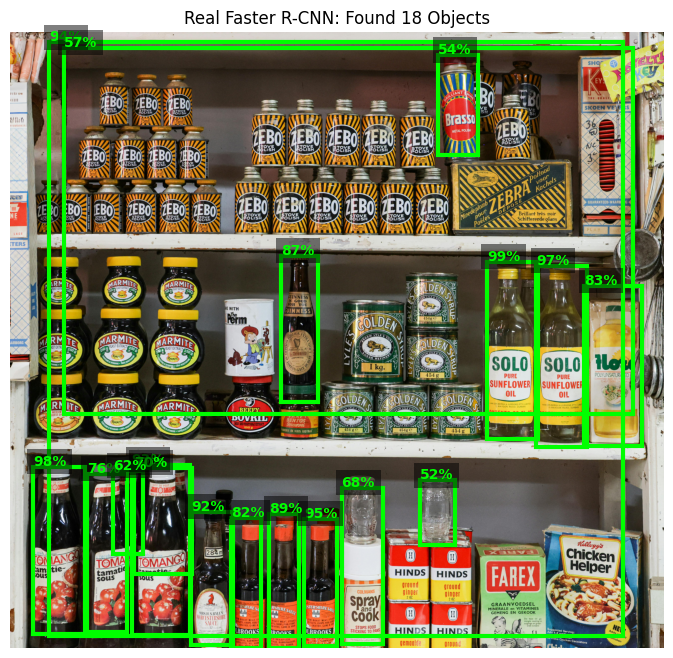

Success! Dynamically detected 18 objects in your image.
Saved visualization to: real_detection_output.jpg


In [38]:

file_path = "/content/object.jpg" # Target image for detection

if not os.path.exists(file_path):
    print(f"Error: '{file_path}' not found. Please upload or place the image in the directory.")
else:
    # Read the image using OpenCV
    img = cv2.imread(file_path)

    # OpenCV loads images in BGR format by default.
    # TensorFlow models expect standard RGB format.
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # The model expects a batch of images as a tensor.
    # Convert to tensor and add a batch dimension: [1, Height, Width, 3]
    img_tensor = tf.convert_to_tensor(img_rgb, dtype=tf.uint8)
    img_tensor = tf.expand_dims(img_tensor, 0)


# 3. INFERENCE

    print("Scanning image for objects...")

    # Run the image through the network.
    # The TF Hub model automatically handles the RPN, ROI Align, and NMS internally.
    results = detector(img_tensor)

    # Extract bounding boxes and confidence scores from the results dictionary.
    # Index [0] is used because we only passed a single image (batch size 1).
    boxes = results["detection_boxes"][0].numpy()
    scores = results["detection_scores"][0].numpy()


# 4. VISUALIZATION & EXPORT

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)

    # Get image dimensions to scale the normalized bounding box coordinates
    h, w, _ = img_rgb.shape

    # Set a confidence threshold to filter out weak/background predictions
    min_confidence = 0.50
    detections = 0

    for i in range(len(scores)):
        if scores[i] >= min_confidence:
            detections += 1

            # The model outputs normalized coordinates between 0 and 1
            # Format: [ymin, xmin, ymax, xmax]
            ymin, xmin, ymax, xmax = boxes[i]

            # Convert normalized coordinates to absolute pixel coordinates
            y1, x1 = int(ymin * h), int(xmin * w)
            y2, x2 = int(ymax * h), int(xmax * w)

            # Draw the bounding box (Green)
            plt.gca().add_patch(
                plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='#00ff00', linewidth=3)
            )

            # Draw the confidence score label
            score_text = f"{scores[i]*100:.0f}%"
            plt.text(
                x1, y1 - 10, score_text, color='#00ff00', fontsize=10, weight='bold',
                bbox=dict(facecolor='black', alpha=0.5, edgecolor='none')
            )

    # Render and save the final image
    plt.title(f"Real Faster R-CNN: Found {detections} Objects")
    plt.axis('off')

    output_filename = "real_detection_output.jpg"
    plt.savefig(output_filename, bbox_inches='tight')
    plt.show()

    print(f"Success! Dynamically detected {detections} objects in your image.")
    print(f"Saved visualization to: {output_filename}")